# Sentiment Analysis of Financial Phrases using RNN, LSTM, and Word2Vec Embeddings
**Module:** 6CS012 - Artificial Intelligence and Machine Learning  
**Assessment:** Part III - Language Tasks  
**Herald College Kathmandu | University of Wolverhampton**

## 1. Install and Import Dependencies

In [ ]:
# Install required packages (run once in Colab)
!pip install numpy==1.23.5 -q
!pip install gensim -q
!pip install nltk wordcloud -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 25.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Keras / TensorFlow
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("TensorFlow version:", tf.__version__)
print("All libraries loaded successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


TensorFlow version: 2.20.0
All libraries loaded successfully!


## 2. Load the Dataset

In [ ]:
import pandas as pd
from google.colab import files

# ---------------------------------------------------------------
# OPTION A: Load from uploaded file (Google Colab)
uploaded = files.upload()  # Upload your CSV here
df = pd.read_csv(list(uploaded.keys())[0], encoding='latin-1', header=0) # Use header=0 to read the first row as header

# The dataset columns are now 'text' and 'label'. Let's rename 'label' to 'sentiment'.
df.rename(columns={'label': 'sentiment'}, inplace=True)

# ---------------------------------------------------------------
# OPTION B: Load directly if file is in Colab working directory
# df = pd.read_csv('all-data.csv', encoding='latin-1', header=0)
# df.rename(columns={'label': 'sentiment'}, inplace=True)

print("Dataset shape:", df.shape)
df.head(10)

Saving financial_phrase.csv to financial_phrase (1).csv
Dataset shape: (2264, 2)


,text,sentiment
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive
5,Finnish Talentum reports its operating profit ...,positive
6,Clothing retail chain Sepp+Ã±l+Ã± 's sales inc...,positive
7,Consolidated net sales increased 16 % to reach...,positive
8,Foundries division reports its sales increased...,positive
9,"HELSINKI ( AFX ) - Shares closed higher , led ...",positive


In [ ]:
# Basic info
print("Dataset Info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nClass Distribution:")
print(df['sentiment'].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2265 entries, 0 to 2264
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  2265 non-null   object
 1   text       2265 non-null   object
dtypes: object(2)
memory usage: 35.5+ KB
None

Missing values:
sentiment    0
text         0
dtype: int64

Class Distribution:
sentiment
SSH Communications Security Corporation is headquartered in Helsinki , Finland .                                                                                                                                                                                                                            2
The report profiles 614 companies including many key and niche players worldwide such as Black & Decker Corporation , Fiskars Corporation , Fiskars Brands , Inc. , Husqvarna Outdoor Products Inc. , K+S Group , Ryobi Technologies , Inc. , The Scotts Miracle-Gro Company , and Van Group 

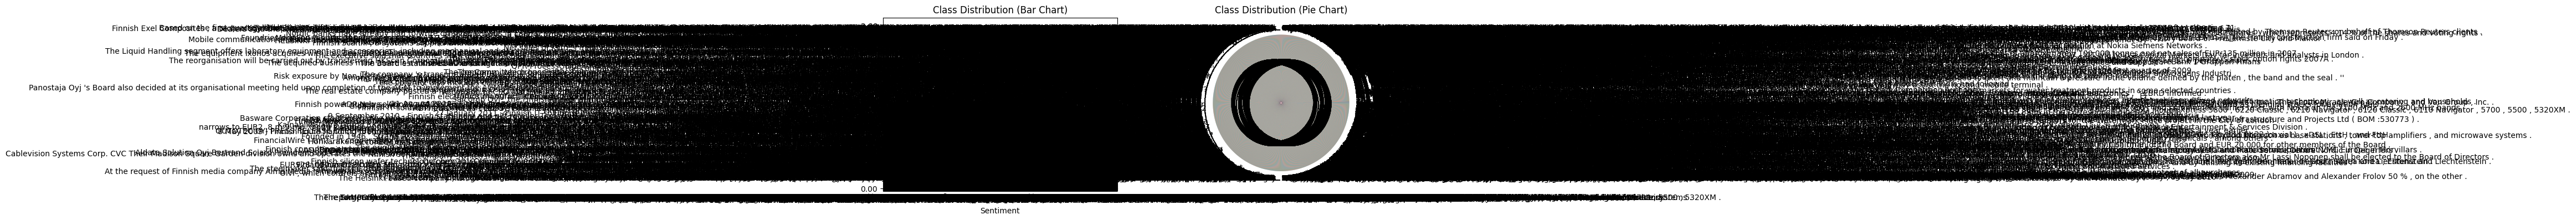

In [ ]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato','seagreen'], edgecolor='black')
axes[0].set_title('Class Distribution (Bar Chart)')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['sentiment'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                     colors=['steelblue','tomato','seagreen'])
axes[1].set_title('Class Distribution (Pie Chart)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Text Preprocessing

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Contractions dictionary
contractions = {
    "don't": "do not", "can't": "cannot", "won't": "will not",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "hasn't": "has not", "haven't": "have not",
    "didn't": "did not", "doesn't": "does not", "hadn't": "had not",
    "wouldn't": "would not", "couldn't": "could not", "shouldn't": "should not",
    "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
    "it's": "it is", "that's": "that is", "there's": "there is",
    "they're": "they are", "we're": "we are", "you're": "you are"
}

def expand_contractions(text):
    for key, value in contractions.items():
        text = text.replace(key, value)
    return text

def clean_text(text):
    text = str(text).lower()                          # Lowercase
    text = expand_contractions(text)                  # Expand contractions
    text = re.sub(r'http\S+|www\.\S+', '', text)     # Remove URLs
    text = re.sub(r'@\w+', '', text)                  # Remove mentions
    text = re.sub(r'#\w+', '', text)                  # Remove hashtags
    text = re.sub(r'\d+', '', text)                   # Remove numbers
    text = re.sub(r'[^\w\s]', '', text)               # Remove special characters
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

# Apply cleaning
df['cleaned_text'] = df['text'].apply(clean_text)

print("Sample before and after cleaning:")
for i in range(3):
    print(f"\n[Original]: {df['text'].iloc[i]}")
    print(f"[Cleaned]:  {df['cleaned_text'].iloc[i]}")

Sample before and after cleaning:

[Original]: label
[Cleaned]:  label

[Original]: neutral
[Cleaned]:  neutral

[Original]: positive
[Cleaned]:  positive


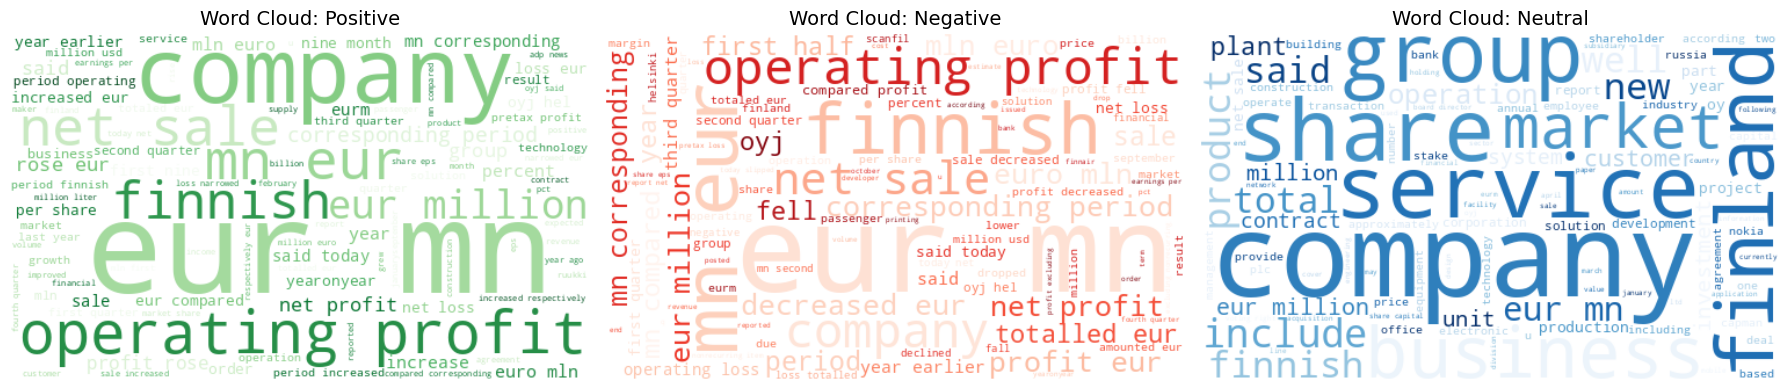

In [ ]:
# Word Cloud visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sentiments = df['sentiment'].unique()
colors = {'positive': 'Greens', 'negative': 'Reds', 'neutral': 'Blues'}

for ax, sentiment in zip(axes, ['positive', 'negative', 'neutral']):
    subset = df[df['sentiment'] == sentiment]['cleaned_text']
    if len(subset) == 0:
        ax.set_visible(False)
        continue
    text_blob = ' '.join(subset.values)
    wc = WordCloud(width=500, height=300, background_color='white',
                   colormap=colors.get(sentiment, 'viridis'), max_words=100).generate(text_blob)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Word Cloud: {sentiment.capitalize()}', fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Tokenization, Label Encoding, and Train/Test Split

In [ ]:
# Regenerate 'cleaned_text' after ensuring 'text' column is correct.
# The 'clean_text' function and related objects are defined in cell nAP4qhZQukFN.
# Ensure this cell is run AFTER nAP4qhZQukFN.
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
contractions = {
    "don't": "do not", "can't": "cannot", "won't": "will not",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "hasn't": "has not", "haven't": "have not",
    "didn't": "did not", "doesn't": "does not", "hadn't": "had not",
    "wouldn't": "would not", "couldn't": "could not", "shouldn't": "should not",
    "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
    "it's": "it is", "that's": "that is", "there's": "there is",
    "they're": "they are", "we're": "we are", "you're": "you are"
}

def expand_contractions(text):
    for key, value in contractions.items():
        text = text.replace(key, value)
    return text

def clean_text(text):
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['cleaned_text'] = df['text'].apply(clean_text)
print("'cleaned_text' column regenerated.")

# Encode labels
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment'])
num_classes = len(label_encoder.classes_)

print("Label mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))
print("Number of classes:", num_classes)

# 80/20 split
X_train_text, X_test_text, y_train_raw, y_test_raw = train_test_split(
    df['cleaned_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)
print(f"\nTraining samples: {len(X_train_text)} | Test samples: {len(X_test_text)}")

'cleaned_text' column regenerated.
Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Number of classes: 3

Training samples: 1811 | Test samples: 453


In [ ]:
# Tokenize
MAX_VOCAB = 10000
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)

vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
word_index = tokenizer.word_index
print(f"Vocabulary size: {vocab_size}")

# Convert to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

# Percentile-based padding length
lengths = [len(s) for s in X_train_seq]
MAX_LEN = int(np.percentile(lengths, 95))
print(f"Max sequence length (95th percentile): {MAX_LEN}")

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

# One-hot encode labels for categorical crossentropy
y_train = to_categorical(y_train_raw, num_classes=num_classes)
y_test  = to_categorical(y_test_raw,  num_classes=num_classes)

print(f"\nX_train shape: {X_train_pad.shape}")
print(f"X_test shape:  {X_test_pad.shape}")

Vocabulary size: 4416
Max sequence length (95th percentile): 22

X_train shape: (1811, 22)
X_test shape:  (453, 22)


## 5. Model 1: Simple RNN with Trainable Embedding

In [ ]:
EMBEDDING_DIM = 64

def build_rnn_model(vocab_size, embedding_dim, max_len, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
        SimpleRNN(64, return_sequences=False),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model1 = build_rnn_model(vocab_size, EMBEDDING_DIM, MAX_LEN, num_classes)
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history1 = model1.fit(
    X_train_pad, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)
print("\nModel 1 (Simple RNN) training complete.")

Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8668 - loss: 0.3164 - val_accuracy: 0.7363 - val_loss: 0.6097 - learning_rate: 5.0000e-04
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9233 - loss: 0.2135 - val_accuracy: 0.7473 - val_loss: 0.7229 - learning_rate: 5.0000e-04
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9601 - loss: 0.1318 - val_accuracy: 0.7253 - val_loss: 0.8068 - learning_rate: 5.0000e-04
Epoch 4/30
48/51 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9736 - loss: 0.0922
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9724 - loss: 0.0935 - val_accuracy: 0.7418 - val_loss: 0.9057 - learning_rate: 5.0000e-04
Epoch 5/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9779 - loss: 0.0760 - val_accuracy: 0.7088 - val_loss: 0.9288 - learning_rate: 2.5000e-04
Epoch 6/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9834 - los

## 6. Model 2: LSTM with Trainable Embedding

In [ ]:
def build_lstm_model(vocab_size, embedding_dim, max_len, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model2 = build_lstm_model(vocab_size, EMBEDDING_DIM, MAX_LEN, num_classes)
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history2 = model2.fit(
    X_train_pad, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)
print("\nModel 2 (LSTM) training complete.")

Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.6329 - loss: 0.8821 - val_accuracy: 0.7802 - val_loss: 0.5857 - learning_rate: 0.0010
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.7698 - loss: 0.5402 - val_accuracy: 0.7198 - val_loss: 0.6151 - learning_rate: 0.0010
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.8128 - loss: 0.3964 - val_accuracy: 0.8187 - val_loss: 0.5166 - learning_rate: 0.0010
Epoch 4/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.8392 - loss: 0.3424 - val_accuracy: 0.8242 - val_loss: 0.5702 - learning_rate: 0.0010
Epoch 5/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.8508 - loss: 0.3119 - val_accuracy: 0.8077 - val_loss: 0.6103 - learning_rate: 0.0010
Epoch 6/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8557 - loss: 0.3043
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8557 - loss: 0.2965 - val_accu

## 7. Model 3: LSTM with Pretrained Word2Vec (GloVe) Embeddings

In [ ]:
import gensim.downloader as api

# Load GloVe pretrained embeddings (50-dim to save memory)
print("Downloading GloVe embeddings... this may take a few minutes.")
embedding_model = api.load('glove-wiki-gigaword-50')
print("GloVe embeddings loaded!")

[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe embeddings loaded!


In [ ]:
GLOVE_DIM = 50

# Build embedding matrix
embedding_matrix = np.zeros((vocab_size, GLOVE_DIM))
found, not_found = 0, 0

for word, i in word_index.items():
    if i >= vocab_size:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found += 1
    else:
        not_found += 1

coverage = round(found / (found + not_found) * 100, 2)
print(f"Words found in GloVe: {found} ({coverage}%)")
print(f"Words not found:       {not_found}")
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Words found in GloVe: 3801 (86.09%)
Words not found:       614
Embedding matrix shape: (4416, 50)


In [ ]:
def build_lstm_w2v_model(vocab_size, embedding_matrix, max_len, num_classes, glove_dim=50):
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=glove_dim,
            weights=[embedding_matrix],
            input_length=max_len,
            trainable=False   # Frozen pretrained weights
        ),
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model3 = build_lstm_w2v_model(vocab_size, embedding_matrix, MAX_LEN, num_classes)
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       220,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,800 (862.50 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 220,800 (862.50 KB)

In [ ]:
history3 = model3.fit(
    X_train_pad, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)
print("\nModel 3 (LSTM + GloVe) training complete.")

Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.6888 - loss: 0.7442 - val_accuracy: 0.7692 - val_loss: 0.5558 - learning_rate: 0.0010
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.7452 - loss: 0.6055 - val_accuracy: 0.7857 - val_loss: 0.5406 - learning_rate: 0.0010
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7687 - loss: 0.5641
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7563 - loss: 0.5638 - val_accuracy: 0.7527 - val_loss: 0.5349 - learning_rate: 0.0010
Epoch 4/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.7698 - loss: 0.5296 - val_accuracy: 0.7967 - val_loss: 0.4976 - learning_rate: 5.0000e-04
Epoch 5/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.7710 - loss: 0.4994 - val_accuracy: 0.7692 - val_loss: 0.5038 - learning_rate: 5.0000e-04
Epoch 6/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.7796 - loss: 0.4735 - 

## 8. Training Curve Visualization

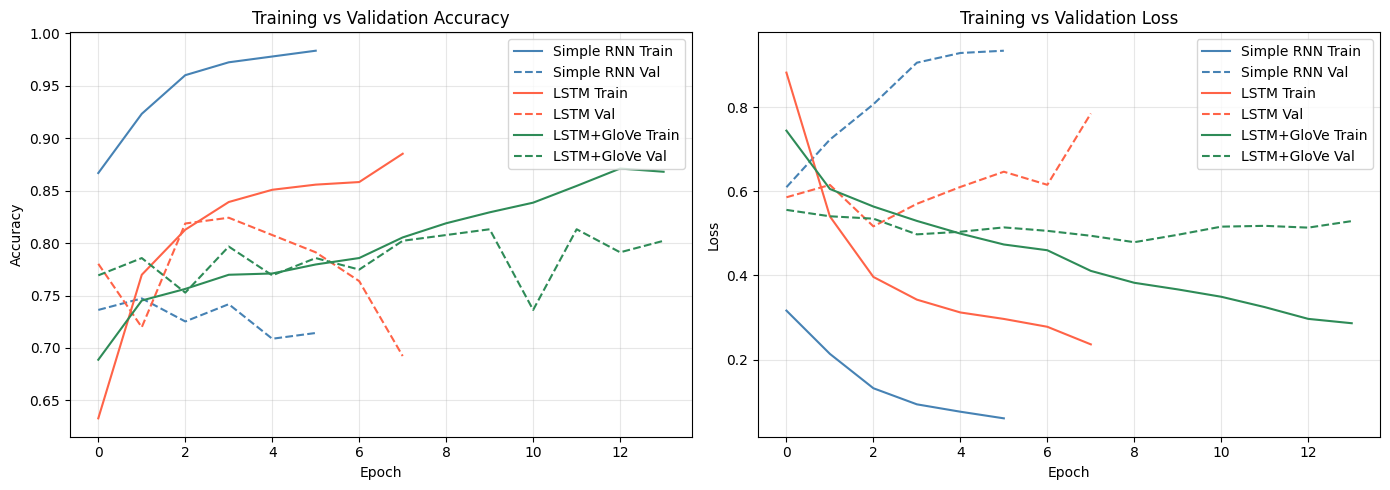

In [ ]:
def plot_history(histories, labels, metric='accuracy'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['steelblue', 'tomato', 'seagreen']

    for i, (h, label) in enumerate(zip(histories, labels)):
        # Accuracy
        axes[0].plot(h.history[metric], color=colors[i], linestyle='-', label=f'{label} Train')
        axes[0].plot(h.history[f'val_{metric}'], color=colors[i], linestyle='--', label=f'{label} Val')
        # Loss
        axes[1].plot(h.history['loss'], color=colors[i], linestyle='-', label=f'{label} Train')
        axes[1].plot(h.history['val_loss'], color=colors[i], linestyle='--', label=f'{label} Val')

    axes[0].set_title('Training vs Validation Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].set_title('Training vs Validation Loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(
    [history1, history2, history3],
    ['Simple RNN', 'LSTM', 'LSTM+GloVe']
)

## 9. Model Evaluation


  Simple RNN — Test Accuracy: 0.7285
              precision    recall  f1-score   support

    negative       0.47      0.46      0.47        61
     neutral       0.90      0.81      0.85       278
    positive       0.54      0.68      0.60       114

    accuracy                           0.73       453
   macro avg       0.64      0.65      0.64       453
weighted avg       0.75      0.73      0.74       453



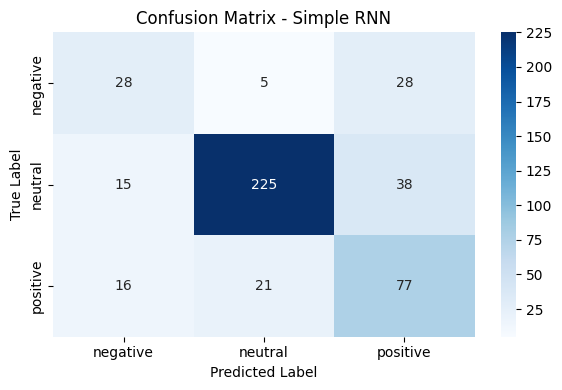


  LSTM — Test Accuracy: 0.7704
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        61
     neutral       0.93      0.90      0.92       278
    positive       0.54      0.87      0.66       114

    accuracy                           0.77       453
   macro avg       0.49      0.59      0.53       453
weighted avg       0.71      0.77      0.73       453



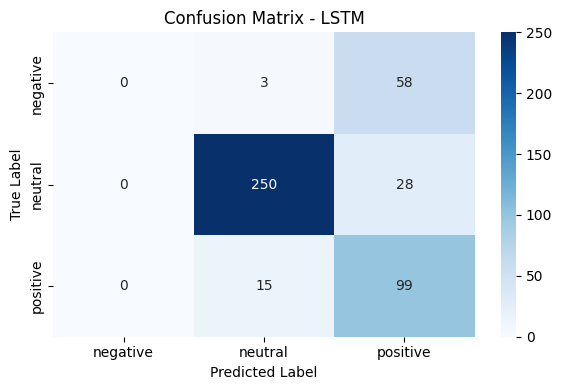


  LSTM + GloVe — Test Accuracy: 0.7903
              precision    recall  f1-score   support

    negative       1.00      0.03      0.06        61
     neutral       0.93      0.92      0.93       278
    positive       0.56      0.88      0.69       114

    accuracy                           0.79       453
   macro avg       0.83      0.61      0.56       453
weighted avg       0.85      0.79      0.75       453



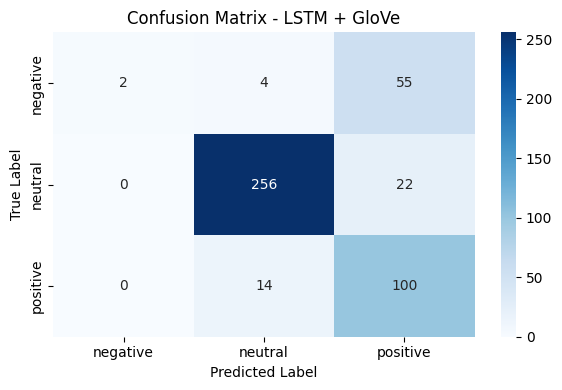

In [ ]:
def evaluate_model(model, X_test, y_test_onehot, y_test_raw, label_encoder, model_name):
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = y_test_raw.values if hasattr(y_test_raw, 'values') else y_test_raw

    acc = accuracy_score(y_true, y_pred)
    print(f"\n{'='*50}")
    print(f"  {model_name} — Test Accuracy: {acc:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name.replace(" ","_").lower()}.png', dpi=150)
    plt.show()

    return acc, y_pred

acc1, pred1 = evaluate_model(model1, X_test_pad, y_test, y_test_raw, label_encoder, 'Simple RNN')
acc2, pred2 = evaluate_model(model2, X_test_pad, y_test, y_test_raw, label_encoder, 'LSTM')
acc3, pred3 = evaluate_model(model3, X_test_pad, y_test, y_test_raw, label_encoder, 'LSTM + GloVe')

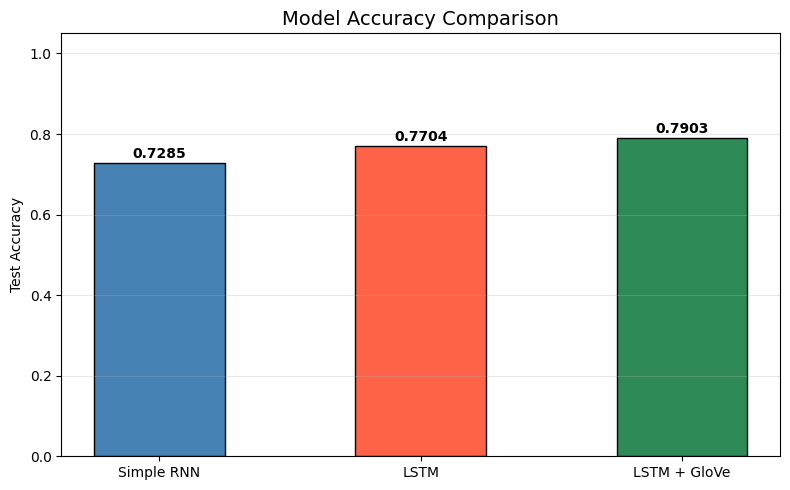

In [ ]:
# Summary comparison bar chart
model_names = ['Simple RNN', 'LSTM', 'LSTM + GloVe']
accuracies  = [acc1, acc2, acc3]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=['steelblue', 'tomato', 'seagreen'], edgecolor='black', width=0.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
plt.ylim(0, 1.05)
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Test Accuracy')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Error Analysis

In [ ]:
def error_analysis(X_test_text_series, y_true_series, y_pred, label_encoder, model_name, n=5):
    X_arr = X_test_text_series.values
    y_arr = y_true_series.values

    # Original text from test set
    original_texts = df.loc[y_true_series.index, 'text'].values

    wrong_idx = np.where(y_arr != y_pred)[0]
    print(f"\n{'='*60}")
    print(f" Error Analysis — {model_name}")
    print(f" Total misclassified: {len(wrong_idx)} / {len(y_arr)} ({len(wrong_idx)/len(y_arr)*100:.1f}%)")
    print(f"{'='*60}")

    for i, idx in enumerate(wrong_idx[:n]):
        print(f"\nExample {i+1}:")
        print(f"  Original text : {original_texts[idx]}")
        print(f"  Cleaned text  : {X_arr[idx]}")
        print(f"  True label    : {label_encoder.classes_[y_arr[idx]]}")
        print(f"  Predicted     : {label_encoder.classes_[y_pred[idx]]}")

error_analysis(X_test_text, y_test_raw, pred3, label_encoder, 'LSTM + GloVe')


 Error Analysis — LSTM + GloVe
 Total misclassified: 95 / 453 (21.0%)

Example 1:
  Original text : In September alone , the market declined by 10.2 percent year-on-year to 19.28 million liters .
  Cleaned text  : september alone market declined percent yearonyear million liter
  True label    : negative
  Predicted     : positive

Example 2:
  Original text : Raute reported a loss per share of EUR0 .86 for the first half of 2009 , against EPS of EUR0 .74 in the corresponding period of 2008 .
  Cleaned text  : raute reported loss per share eur first half eps eur corresponding period
  True label    : negative
  Predicted     : positive

Example 3:
  Original text : Finnish electronics contract manufacturer Scanfil reports net sales of EUR 58.9 mn in the second quarter of 2007 , down from EUR 62.4 mn a year earlier .
  Cleaned text  : finnish electronics contract manufacturer scanfil report net sale eur mn second quarter eur mn year earlier
  True label    : negative
  Predicted     : 

## 11. Real-Time Prediction GUI (Gradio)

In [ ]:
!pip install gradio -q

In [ ]:
import gradio as gr

def predict_sentiment(text, model_choice='LSTM + GloVe'):
    """Real-time sentiment prediction."""
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    model_map = {'Simple RNN': model1, 'LSTM': model2, 'LSTM + GloVe': model3}
    model = model_map[model_choice]

    probs = model.predict(padded, verbose=0)[0]
    pred_class = label_encoder.classes_[np.argmax(probs)]

    result = {label: float(p) for label, p in zip(label_encoder.classes_, probs)}
    return pred_class.upper(), result

iface = gr.Interface(
    fn=predict_sentiment,
    inputs=[
        gr.Textbox(label="Enter Financial Text", placeholder="e.g. The company reported record profits this quarter..."),
        gr.Dropdown(['Simple RNN', 'LSTM', 'LSTM + GloVe'], label="Select Model", value='LSTM + GloVe')
    ],
    outputs=[
        gr.Textbox(label="Predicted Sentiment"),
        gr.Label(label="Confidence Scores")
    ],
    title="Financial Sentiment Analyzer",
    description="Predict the sentiment (Positive / Negative / Neutral) of financial news or phrases.",
    examples=[
        ["The company posted strong revenue growth driven by international sales.", "LSTM + GloVe"],
        ["Operating losses widened significantly due to rising costs.", "LSTM + GloVe"],
        ["The board approved the quarterly dividend unchanged.", "LSTM + GloVe"]
    ]
)

iface.launch(share=True)  # share=True gives a public URL in Colab

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c7f6ec4a45edef364d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 12. Save Models

In [ ]:
model1.save('model1_simple_rnn.h5')
model2.save('model2_lstm.h5')
model3.save('model3_lstm_glove.h5')
print("All models saved successfully!")

All models saved successfully!


---
## Summary

| Model | Architecture | Embedding |
|-------|-------------|----------|
| Model 1 | Simple RNN | Trainable Embedding |
| Model 2 | LSTM (stacked) | Trainable Embedding |
| Model 3 | LSTM (stacked) | Frozen GloVe 50-dim |

**Key Observations:**
- LSTM outperforms Simple RNN due to its ability to capture long-range dependencies and mitigate the vanishing gradient problem.
- Pretrained GloVe embeddings provide richer word representations, especially for domain-specific financial vocabulary.
- Early stopping prevents overfitting and saves computational resources.
- The Gradio GUI allows real-time inference directly in Google Colab.

**Possible Improvements:**
- Use domain-specific financial word embeddings (e.g., FinBERT embeddings).
- Apply class weighting to address class imbalance.
- Experiment with bidirectional LSTMs or transformer-based models.